In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vae_definition import VAE
import torch

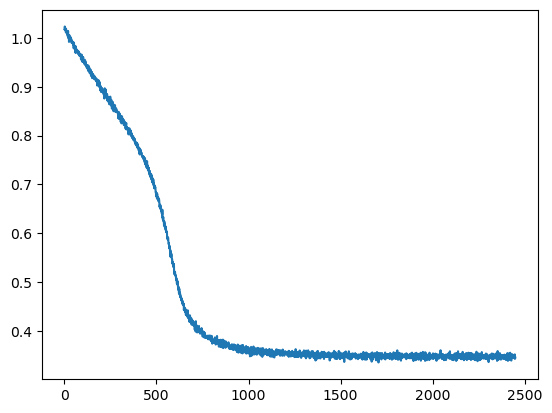

In [12]:
fig, ax = plt.subplots()
losses = np.load("vae_losses.npy")

ax.plot(losses)

torch.Size([1000, 32])
tensor([[ 7.1380e-01,  1.1095e-08,  9.9707e-03, -3.8394e-06, -6.6495e-04,
          1.1238e-02],
        [ 7.0750e-01,  1.1038e-08,  9.9533e-03, -4.1991e-06, -5.9080e-04,
          1.0775e-02],
        [ 7.1597e-01,  1.1114e-08,  9.9766e-03, -3.7164e-06, -6.9040e-04,
          1.1396e-02],
        ...,
        [ 7.0247e-01,  1.0993e-08,  9.9394e-03, -4.4964e-06, -5.3099e-04,
          1.0396e-02],
        [ 7.1869e-01,  1.1139e-08,  9.9845e-03, -3.5623e-06, -7.2223e-04,
          1.1593e-02],
        [ 7.1165e-01,  1.1076e-08,  9.9645e-03, -3.9609e-06, -6.3977e-04,
          1.1081e-02]])


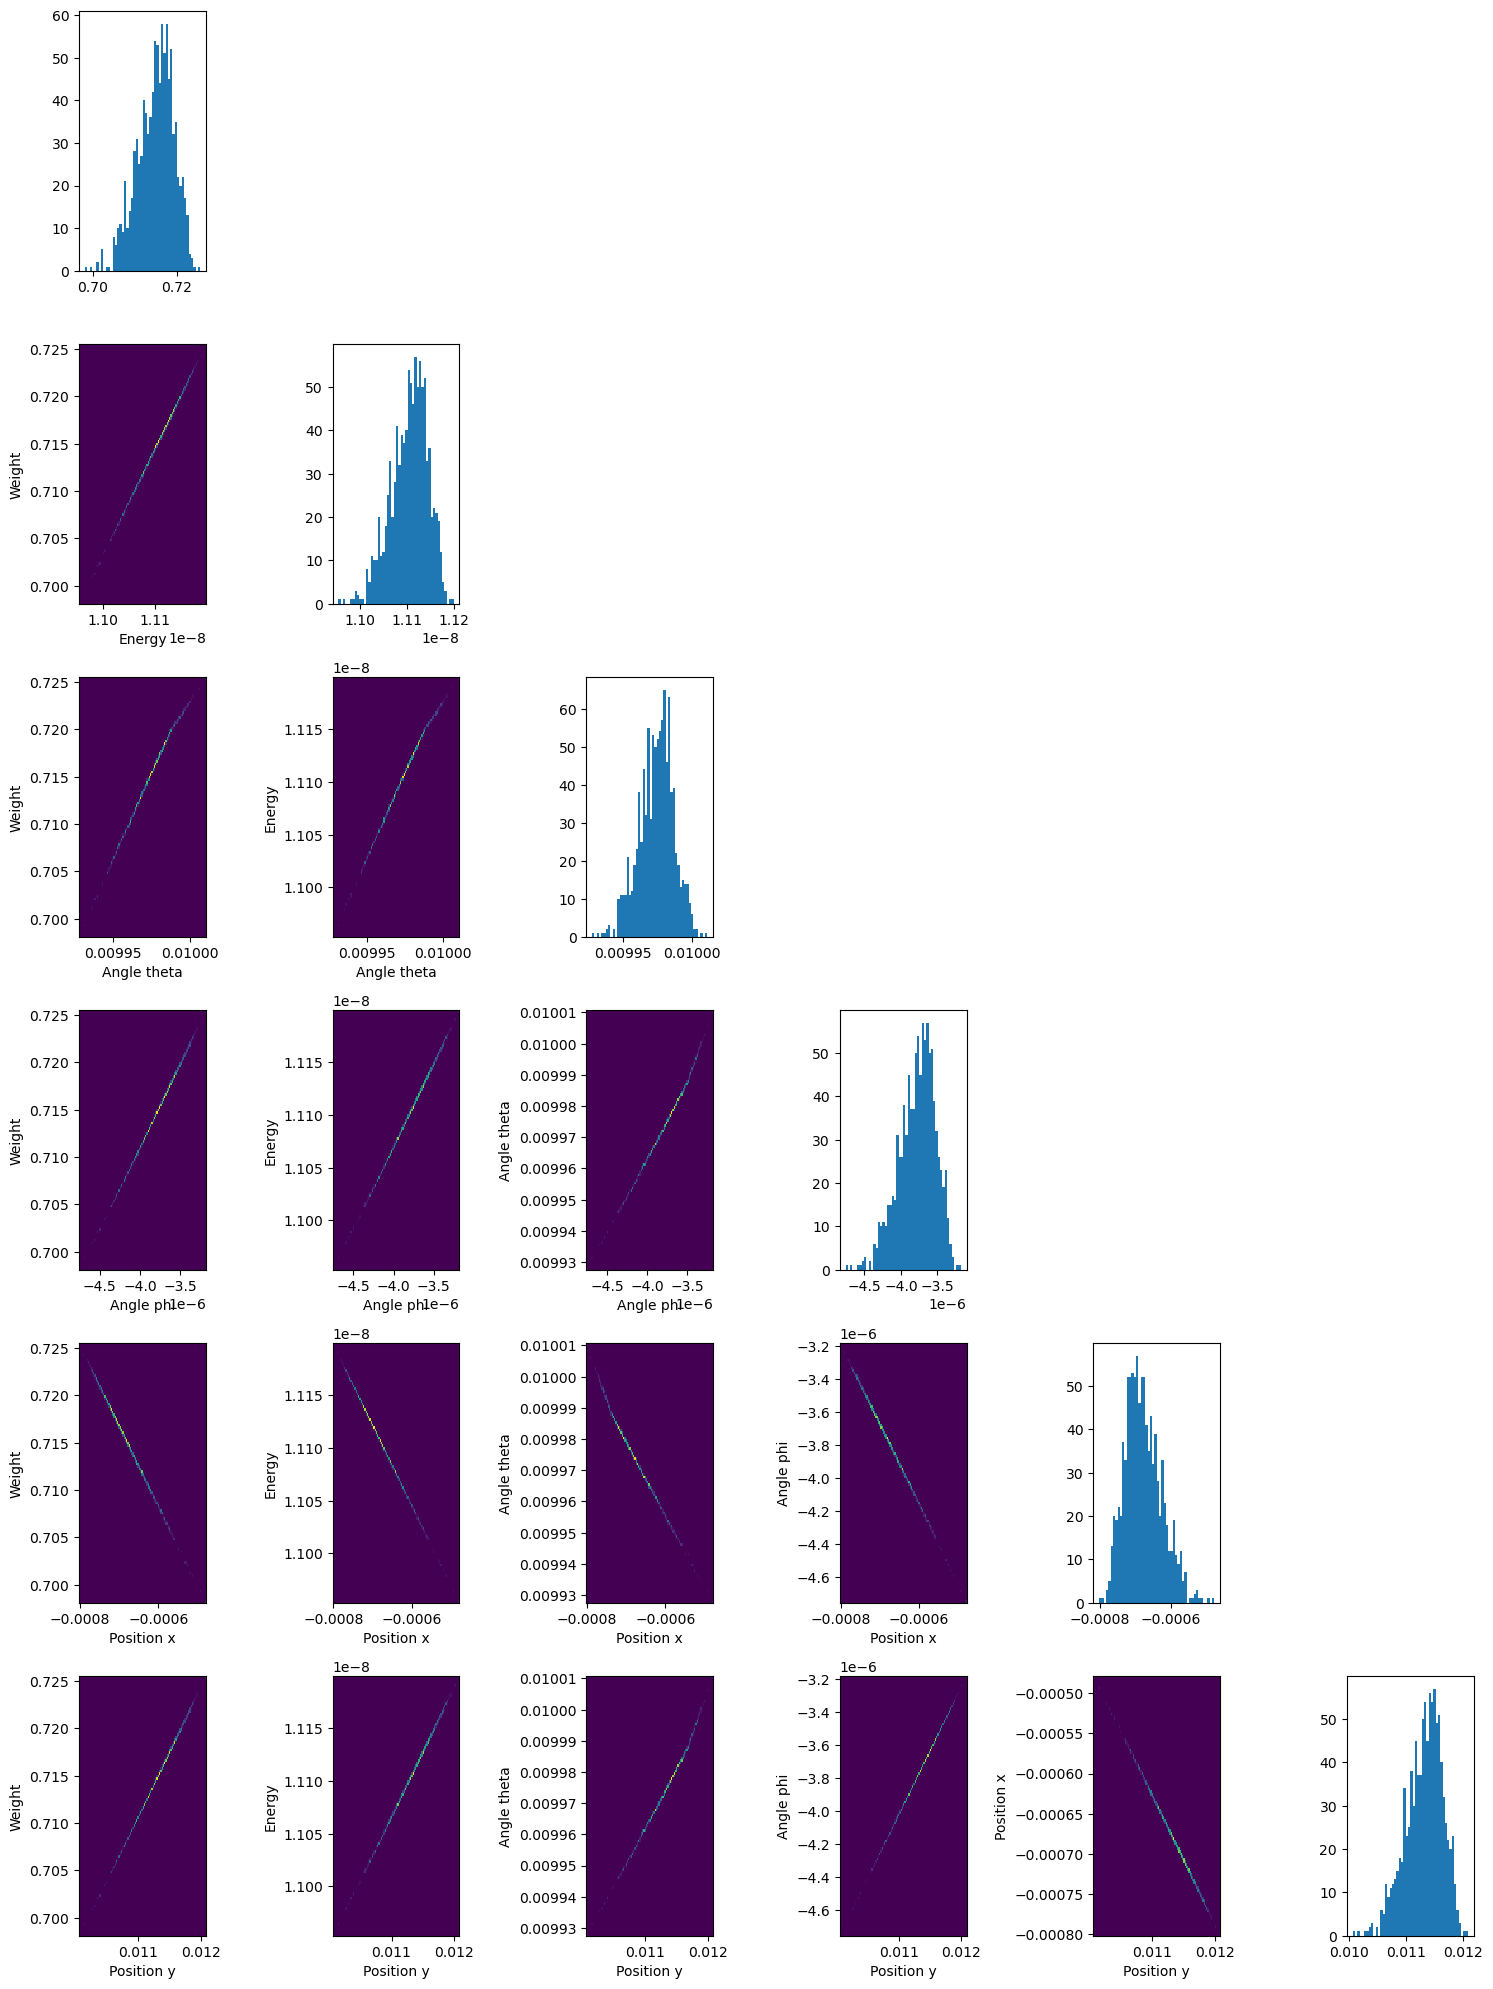

In [13]:
# sample_from_vae.py
device = "mps"

ckpt = torch.load("vae.pth", map_location=device)

vae = VAE().to(device)
vae.load_state_dict(ckpt["state_dict"])
vae.eval()

mins = ckpt["mins"].to(device)       
scales = ckpt["scales"].to(device)  


labels = ["Weight", "Energy", "Angle theta", "Angle phi", "Position x", "Position y"]
with torch.no_grad():
    z = torch.randn(1000,32).to(device)  # sample 1000 latent vectors
    print(z.shape)
    samples = vae.decode(z)              # synthetic data in [0,1]
    samples = samples.clamp(0,1)
    samples = samples * scales + mins
samples = samples.cpu()
print(samples.cpu())
fig, ax = plt.subplots(ncols=6, nrows=6, figsize=(15,20))
for i in range(6):
    for j in range(6):
        if j>i:
            ax[i,j].set_axis_off()
            continue
        if j==i and i!= 7:
            ax[i,j].hist(samples[:,i], bins=50)
            continue
        ax[i,j].hist2d(samples[:,i], samples[:,j], bins=100)
        ax[i,j].set(xlabel=labels[i], ylabel=labels[j])
plt.tight_layout()